In [1]:
from plantcv import plantcv as pcv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import cv2
from collections import Counter
import os
import skimage.io as io
from skimage.filters import threshold_otsu, threshold_yen, threshold_multiotsu
import skimage.util as util
import colorsys
import skimage.morphology as morph
import pandas as pd
import skimage.measure as measure

# Functions

In [2]:
"""
Function for using K-Means to cluster colours in an image

inputs: cv2 image = image you want to perform K-means analysis on
number_of_colours = int number of clusters you want to group colours into
show_chart = boolean to output resultant chart to file or not
filename = string to save chart to if show_chart is true

output: a chart showing the number_of_colours groups that colours were grouped into with the size of each piece representing a proportion of that colour and the colour of the piece being the value of the centroid 

other: background of input should be all black, these pixels are grouped together and dropped from chart
"""
def get_dominant_colors(image, number_of_colors, show_chart,filename):
    print(filename)
    # account for black pixels
    number_of_colors = number_of_colors + 1
    # reshape image for Kmeans
    reshaped_image = cv2.resize(image, (600, 400))
    reshaped_image = reshaped_image.reshape(reshaped_image.shape[0]*reshaped_image.shape[1], 3)
    # cluster pixels
    clf = KMeans(n_clusters = number_of_colors)
    labels = clf.fit_predict(reshaped_image)
    counts = Counter(labels)
    counts = dict(sorted(counts.items()))
    center_colors = clf.cluster_centers_
    ordered_colors = [center_colors[i] for i in counts.keys()]

    # iterate through colours and find which array i is black
    black = 3
    for i in range(number_of_colors):
        color_array = ordered_colors[i]
        if color_array[0] <= 10 and color_array[1] <= 10 and color_array[2] <= 10:
            black = i
    # remove it and pop that key from counts
    del ordered_colors[black]
    counts.pop(black)
    
    # then make hex and rgb
    hex_colors = [RGB_HEX(ordered_colors[i]) for i in range(number_of_colors-1)]
    rgb_colors = [ordered_colors[i] for i in range(number_of_colors-1)]

    # only save figure if show_chart is True
    if (show_chart):

        name = filename.split('/')[-1]
        plt.figure(figsize = (8, 6))
        plt.title(name)
        plt.pie([list(counts.values())[0], list(counts.values())[1]], labels = [hex_colors[0], hex_colors[1]], colors = [hex_colors[0], hex_colors[1]])
        plt.savefig('../../results/charts'+ '/'+name)
    return rgb_colors
"""
A helper function to format a color as HEX color
inupt: a string of a color in rgb
output: a string of the hex code of input color 
"""
def RGB_HEX(color):
    return "#{:02x}{:02x}{:02x}".format(int(color[0]), int(color[1]), int(color[2]))

In [3]:
"""
Calculate the mean rgb values of an image

input: wheathead_img = a cv2 img, named for originally being wheatheads but can be any object on white or black background!

output: the mean rgb value of objects in an image and the count of number of pixels that objects take up in the image

other: img must have
"""
def get_average_color(wheathead_img):
    average = []
    r_sum = int(0)
    g_sum = int(0)
    b_sum = int(0)
    count = int(0)
    for i in range(wheathead_img.shape[0]):
        for j in range(wheathead_img.shape[1]):
            if wheathead_img[i][j][0] != 0 and wheathead_img[i][j][1] != 0 and wheathead_img[i][j][2] != 0:
                count += 1
                r_sum = r_sum + int(wheathead_img[i][j][0])
                g_sum+=int(wheathead_img[i][j][1])
                b_sum+=int(wheathead_img[i][j][2])
               
    return([r_sum/count, g_sum/count, b_sum/count]) 

In [4]:
"""
Function for calculating percent area covered in pustules from symptomatic stripe or leaf rust images

filename = the name of the file containing the segmented image of a symptomatic wheat leaf

returns: percent area covered in pustules, optional mask 

other: background of input should be all black
"""
def calc_pustule_percent(filename, return_mask = False):
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    bgr_normalized = img/255.0
    
    R = bgr_normalized[:, :, 0]
    G = bgr_normalized[:, :, 1]
    B = bgr_normalized[:, :, 2]
    
    # Calculate Black (K) channel
    K = 1.0 - np.max(bgr_normalized, axis=2)
    
    # Calculate Cyan, Magenta, Yellow channels safely (avoid divide by zero)
    # np.where handles pure black pixels where K == 1
    
    M = np.where(K < 1.0, (1.0 - G - K) / (1.0 - K), 0.0)
    
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
       
    _, leaf_mask = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    # get rid of the edges    
    kernel = np.ones((5,5), np.uint8)
    
    leaf_mask = cv2.morphologyEx(
        leaf_mask,
        cv2.MORPH_OPEN,
        kernel
    )
    
    
    leaf_mask = cv2.morphologyEx(
        leaf_mask,
        cv2.MORPH_CLOSE,
        kernel)
    kernel = np.ones((7,7), np.uint8)
        # get rid of weird artifact from SAM
    leaf_mask = cv2.erode(
          leaf_mask.astype(np.uint8),
          kernel,
         iterations=2).astype(bool)
    
    
    masked_pixels = M[leaf_mask == True]
    thresh1 = threshold_otsu(masked_pixels)
    
    total_pixels = np.sum(leaf_mask)
    
    rust_percent = np.sum((M > thresh1)&leaf_mask) / total_pixels * 100
    
    if return_mask:
        return rust_percent, (M > thresh1)&leaf_mask
    return rust_percent

In [5]:
"""
Function for counting the number of pustules on the surface of a leaf, used for leaf rust

filename = the name of the file containing the segmented image of a symptomatic wheat leaf

returns: count of pustules 

other: background of input should be all black, will call calc_pustule_percent
"""
def pustule_count(filename):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    _, mask = calc_pustule_percent(filename, True)
    # Apply closing to fill inner gaps, then opening to clear out outer noise
    smoothed = cv2.morphologyEx(mask.astype('float64'), cv2.MORPH_CLOSE, kernel)
    smoothed_mask = cv2.morphologyEx(smoothed, cv2.MORPH_OPEN, kernel)
    # count components and remove the large ones
    components = measure.label(smoothed_mask)
    large_areas = morph.remove_small_objects(components, max_size=5000)
    pustules = components ^ large_areas
    _, count = measure.label(pustules,return_num = True)
    return count

# Sample Workflow for Leaf Rust

In [11]:
# read in the leaves
leaves = []

directory = '../../auto_segment/Avocet+Yr15-R2-2/'
files = sorted(os.listdir(directory))

for file in files[-3:-2]:
    leaf = []
    leaf.append(directory+file)
    leaves.append(leaf)

../../auto_segment/Avocet+Yr15-R2-2/Avocet+Yr15-R2-2_BiglabPhone 5_20251201_231409_000.jpeg


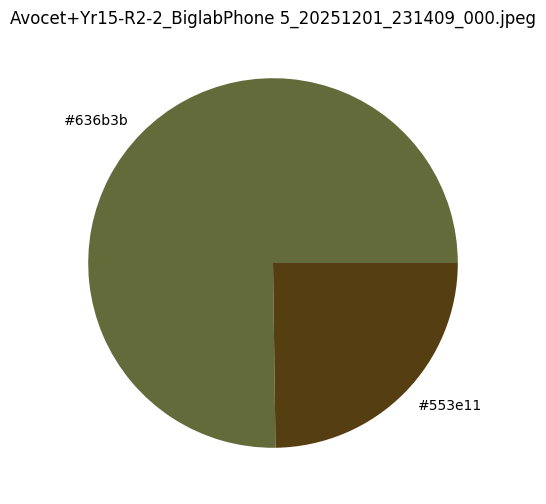

In [12]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
# calculate dominant and mean colors for the images
for i in range(len(leaves)):
    filename = leaves[i][0]
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # this cluster step is longest step
    colors = get_dominant_colors(img, 2, True, filename)
    leaves[i].append(colors)
    total_pixels = np.sum(np.all(img > 0, axis=2))
    mean_color = get_average_color(img)
    leaves[i].append(mean_color)
    leaves[i].append(total_pixels)
    num_pustules = pustule_count(filename)
    leaves[i].append(num_pustules)

In [9]:
df = pd.DataFrame(leaves[:][:])
df.columns = ['filename','Kmeans_results','mean_colour', 'pixels', 'Pustule Count']
df 

,filename,Kmeans_results,mean_colour,pixels,Pustule Count
0,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[120.06857142857132, 121.57142857142853, 88.4...","[68.83991551659288, 77.04876602146804, 38.3771...",69126,0
1,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[63.71847246891598, 74.13765541740693, 33.235...","[69.16923570034092, 78.08454500422506, 39.9666...",68638,0
2,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[62.38611925708694, 73.2199413489737, 32.9951...","[66.50420869906984, 76.16053648630944, 38.6108...",61064,0
3,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[62.982638888886804, 73.65885416666545, 31.26...","[75.44965009752896, 83.67170643321346, 41.7323...",216346,4
4,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[63.19270833333333, 73.58333333333326, 31.315...","[75.24133526903852, 83.06968079241399, 41.7272...",217664,2
5,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[62.58976582827265, 72.18589187626382, 29.694...","[76.62866112455715, 83.10298502227367, 40.0231...",228072,3
6,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[138.42926829268265, 134.1780487804877, 88.08...","[75.60833115128061, 82.9253161017739, 40.89223...",225323,3
7,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[140.58076448828638, 135.8483353884098, 89.04...","[77.18612389627857, 84.47501724905895, 42.0144...",228998,3
8,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[141.07013815090357, 136.54622741764038, 88.6...","[79.49140640821322, 86.11798578887587, 43.5742...",227146,4
9,../../auto_segment/Avocet+Yr15-R3-2/Avocet+Yr1...,"[[140.795758928571, 136.3058035714292, 87.9006...","[79.19797571739083, 86.5241969833359, 43.05593...",227735,2


In [11]:
df.to_csv('../../example_leafrust.csv')

# Sample Workflow for Stripe Rust

In [14]:
# read in the leaves
leaves = []

directory = '../../striperust_spring2025/auto_segment/Avocet-3/'
files = sorted(os.listdir(directory))

for file in files[:]:
    leaf = []
    leaf.append(directory+file)
    leaves.append(leaf)

../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250219_235809_370.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250220_020809_420.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250220_130809_555.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250220_235809_696.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250221_020809_727.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250221_130810_132.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250221_235810_531.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250222_020810_602.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250222_130810_757.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250222_235810_925.jpeg
../../striperust_spring2025/auto_segment/Avocet-3/Avocet-3_Device1_20250223_0208

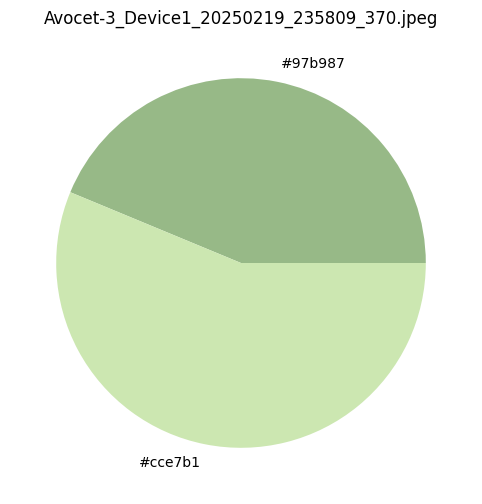

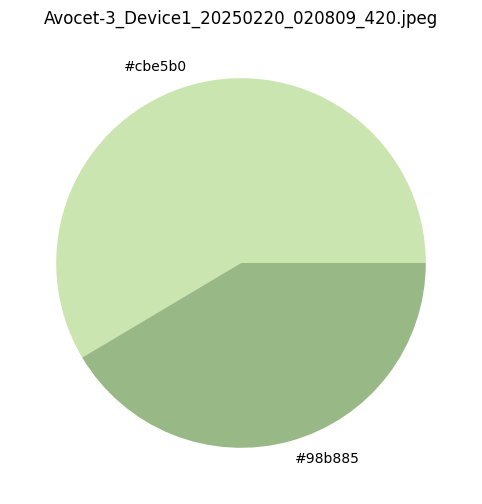

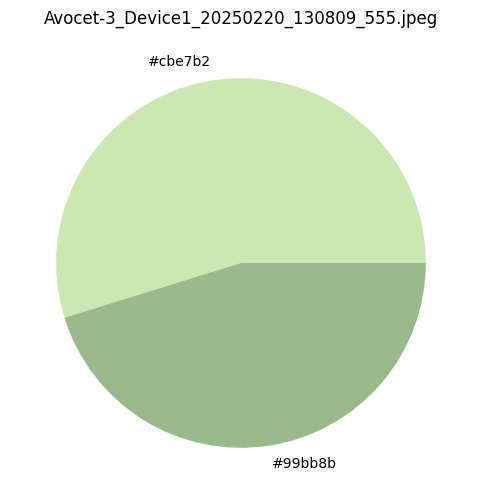

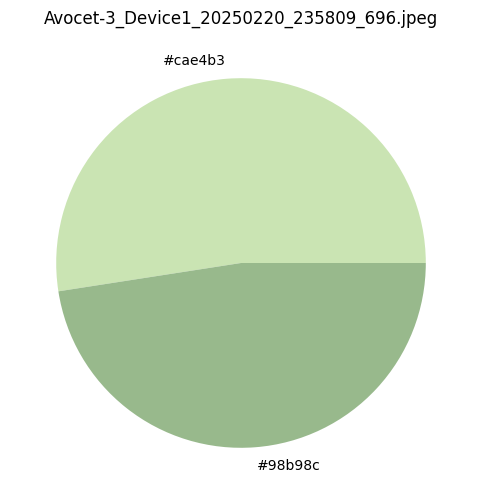

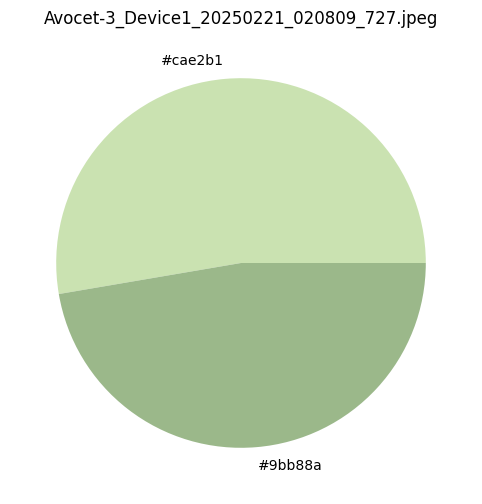

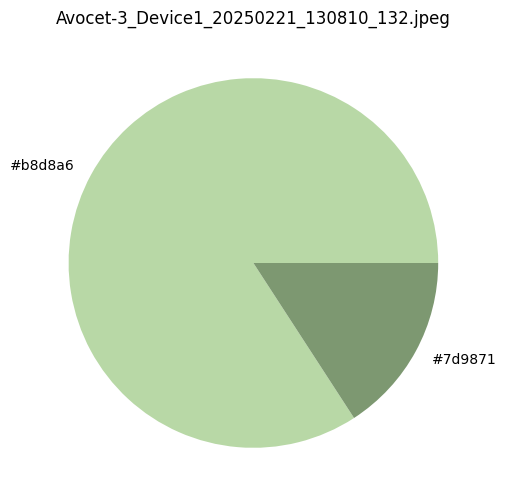

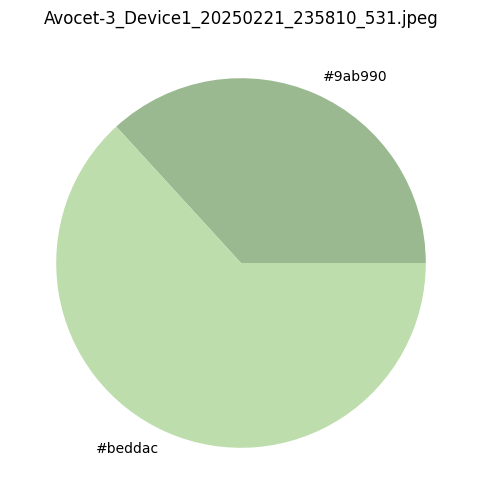

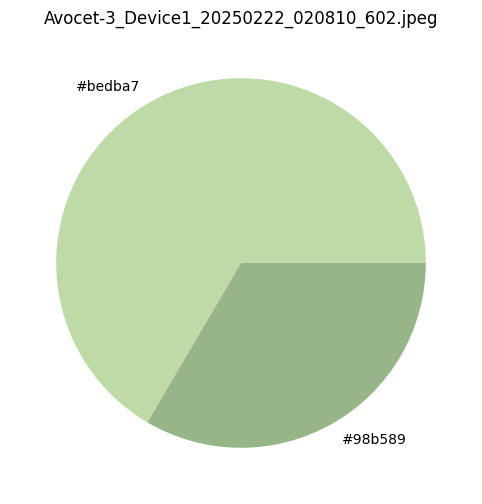

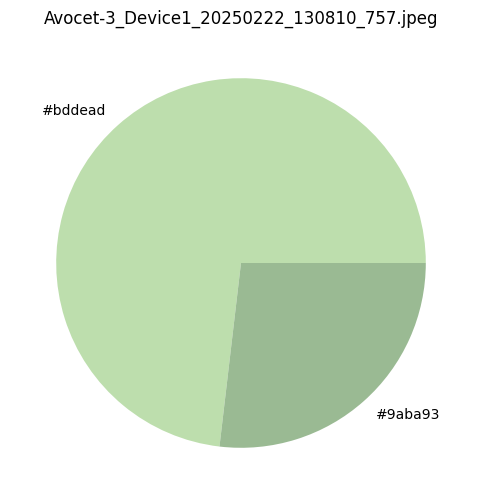

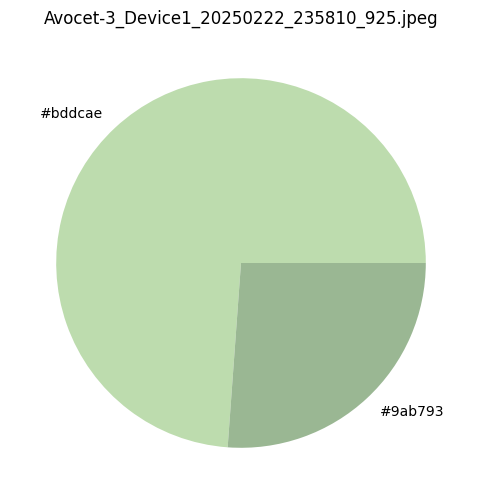

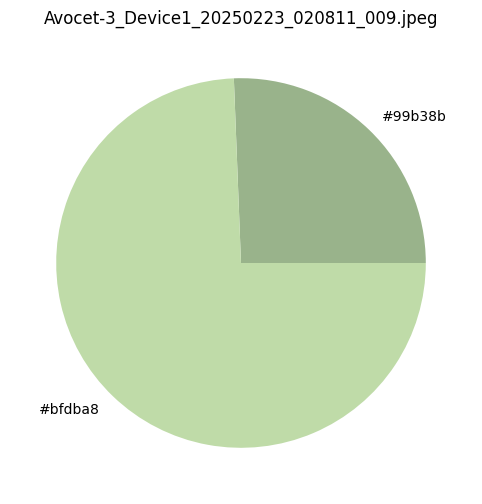

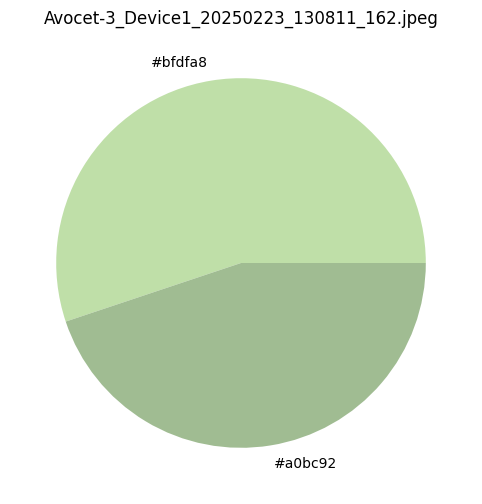

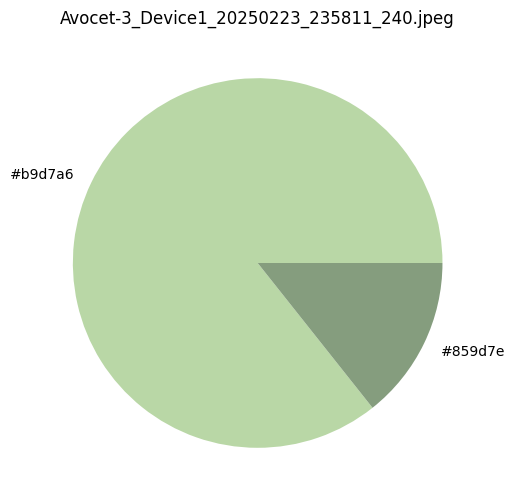

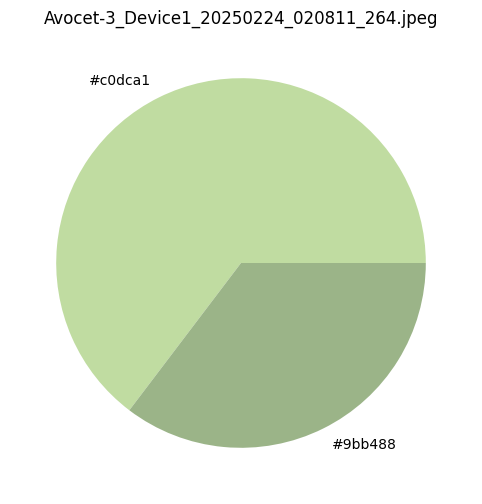

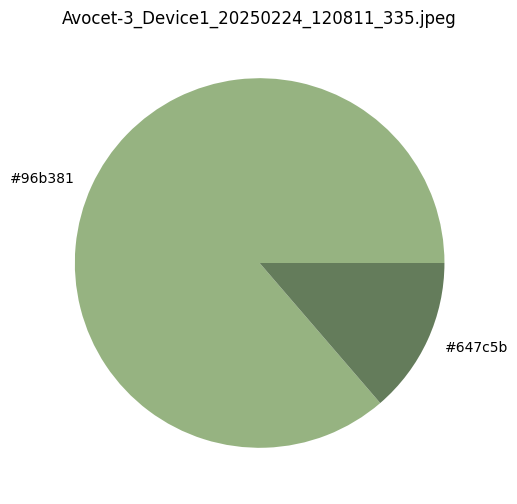

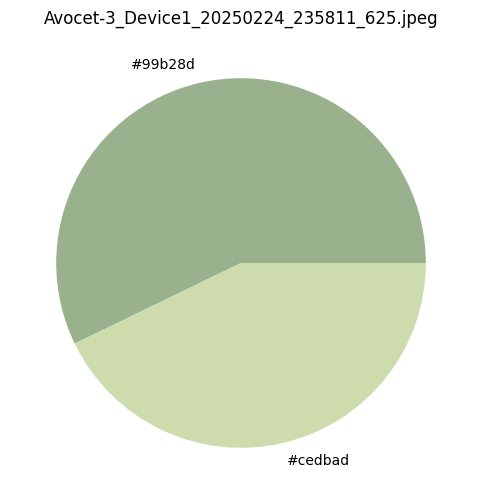

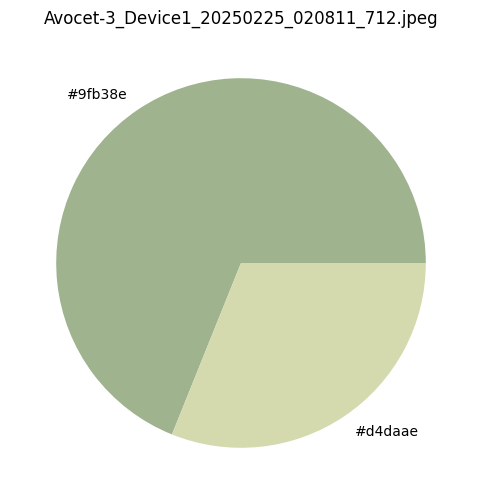

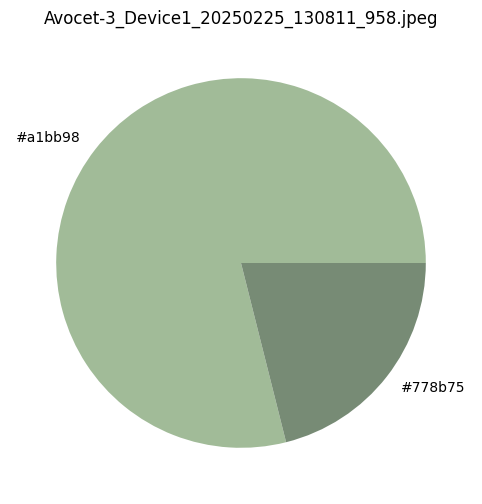

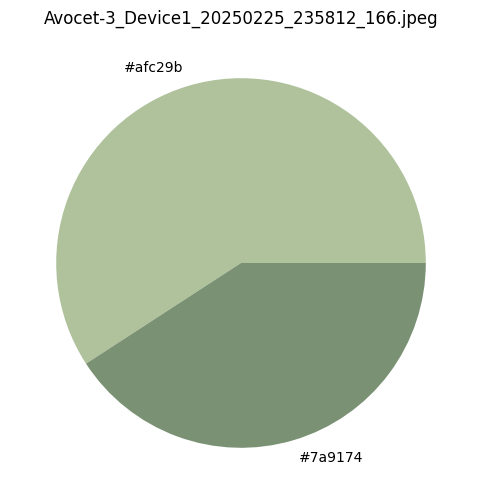

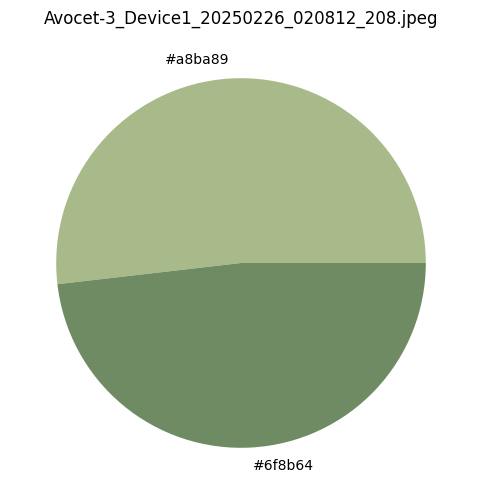

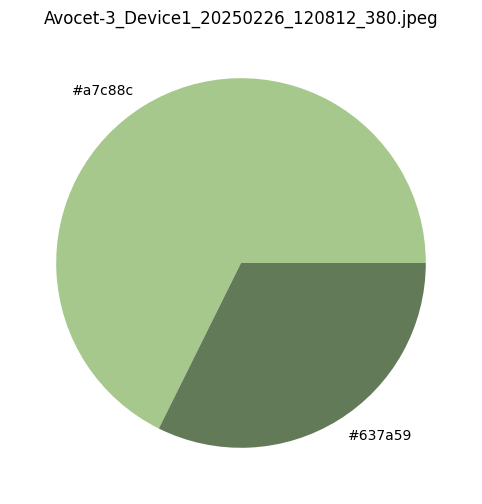

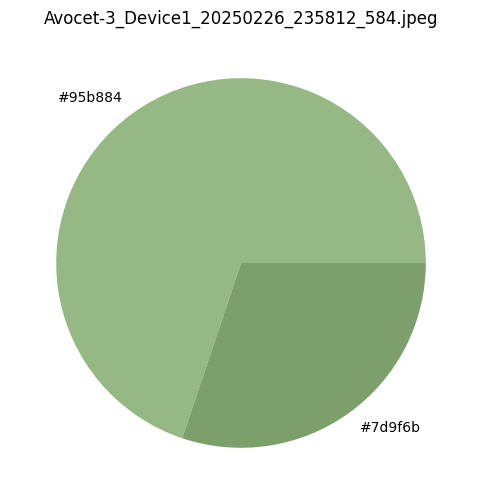

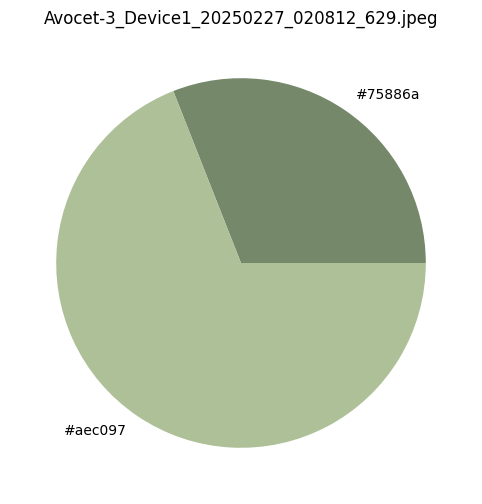

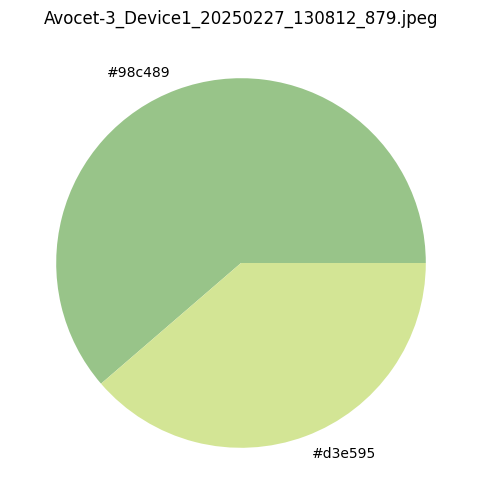

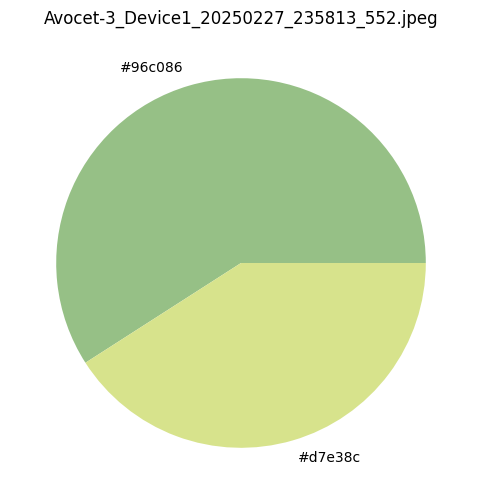

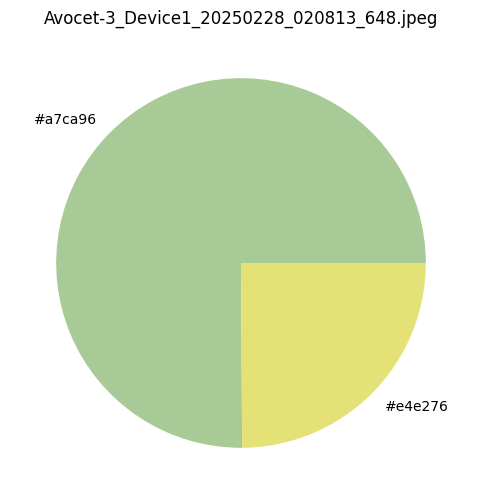

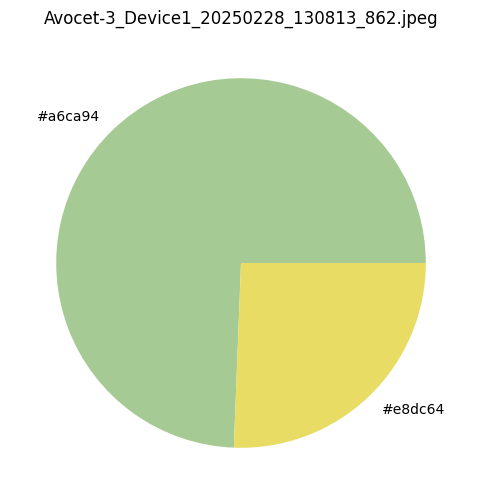

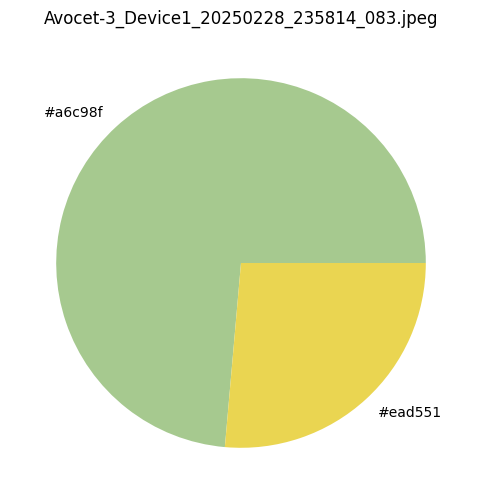

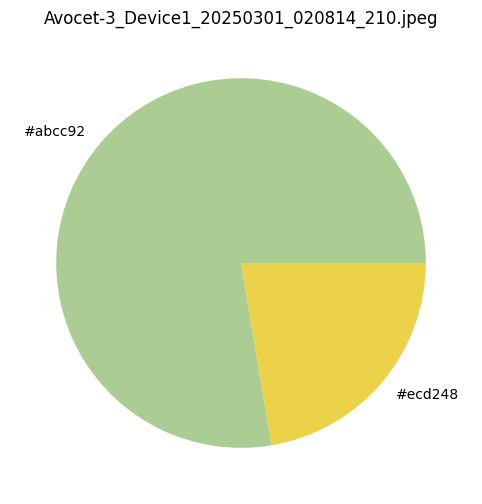

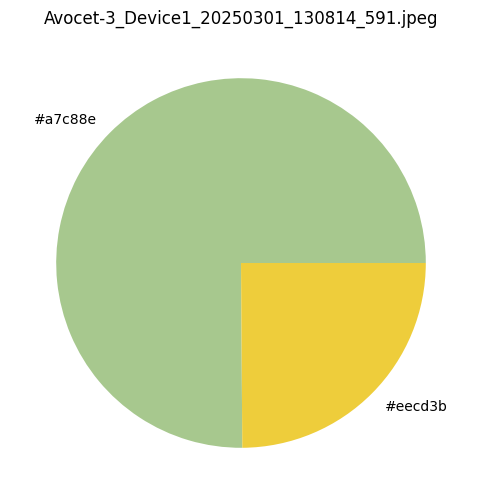

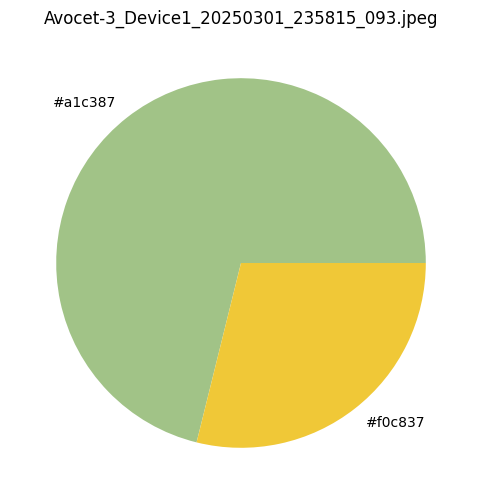

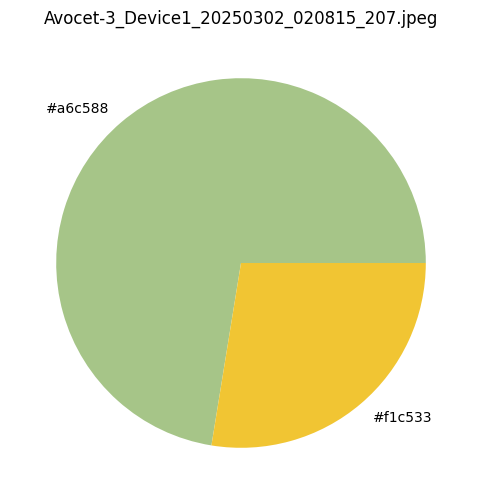

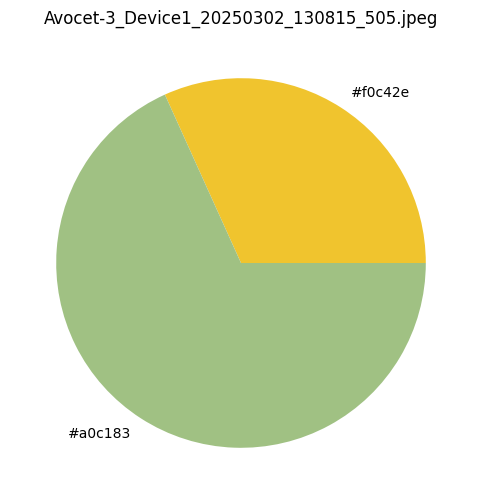

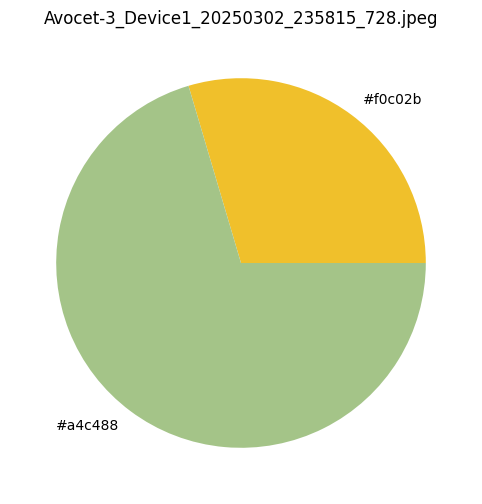

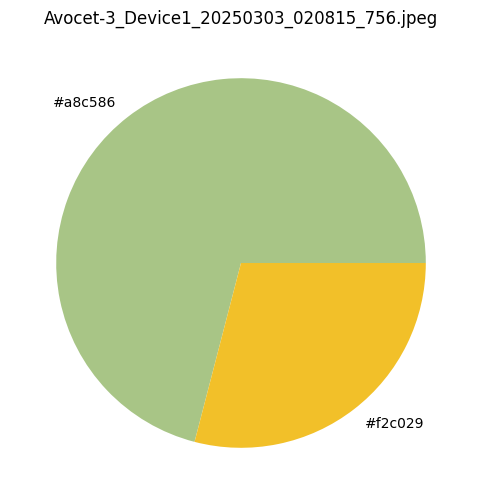

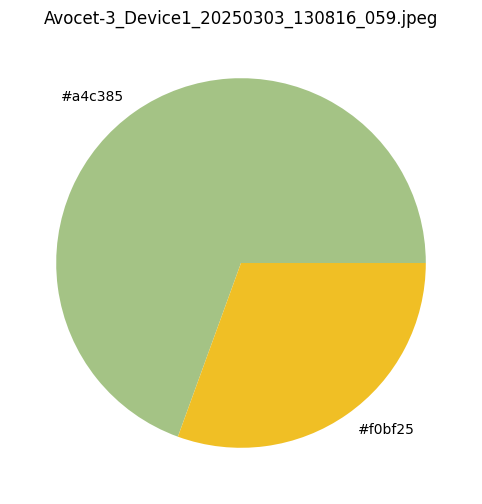

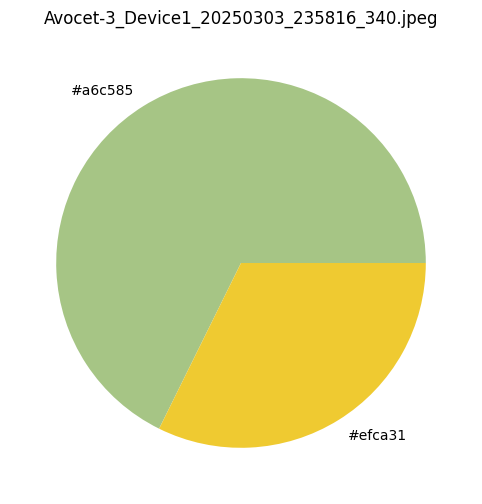

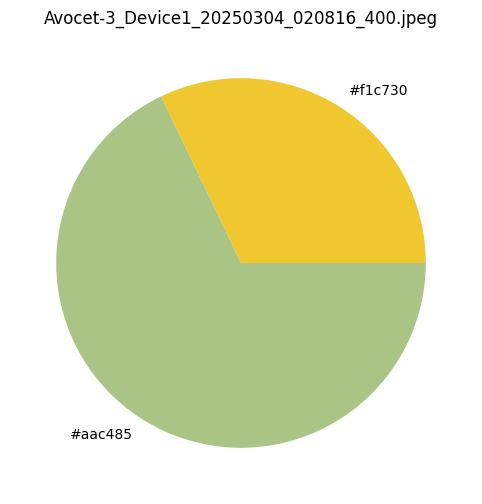

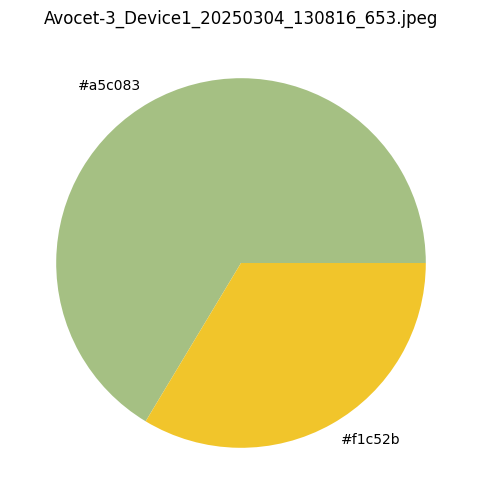

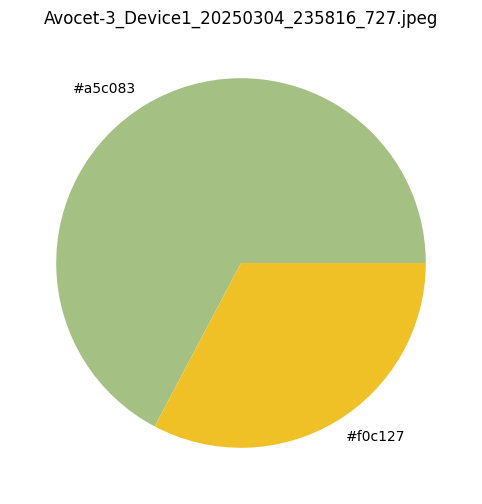

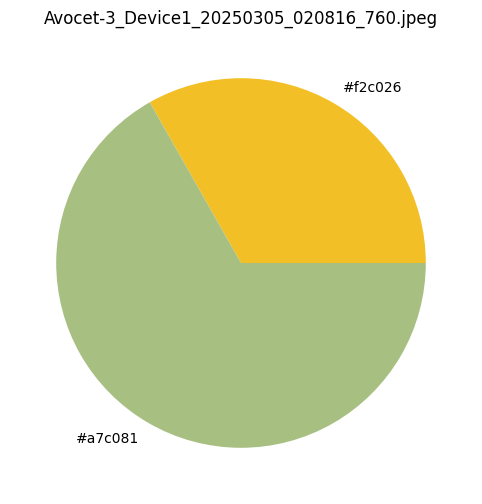

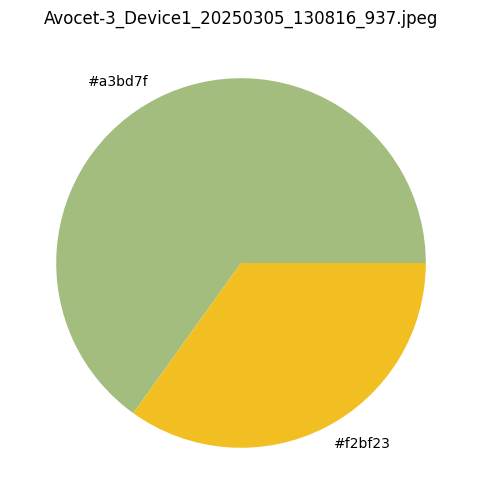

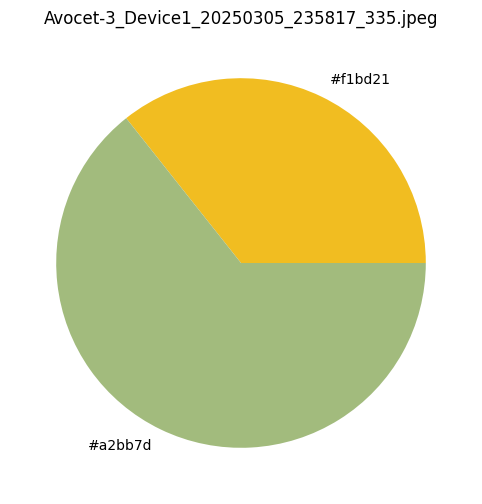

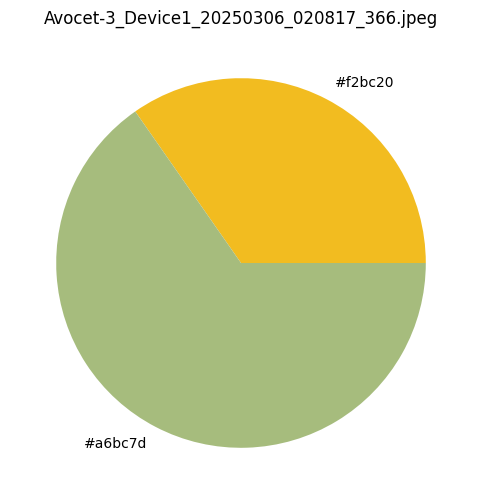

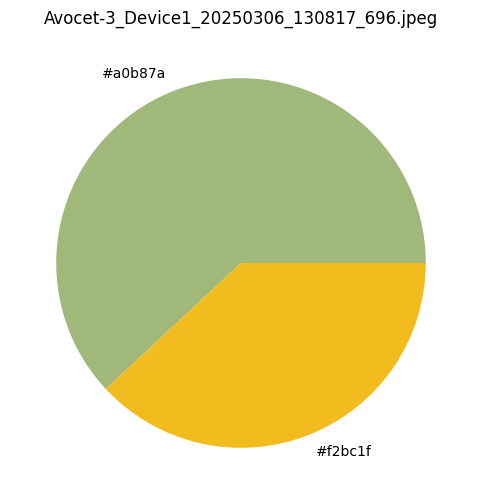

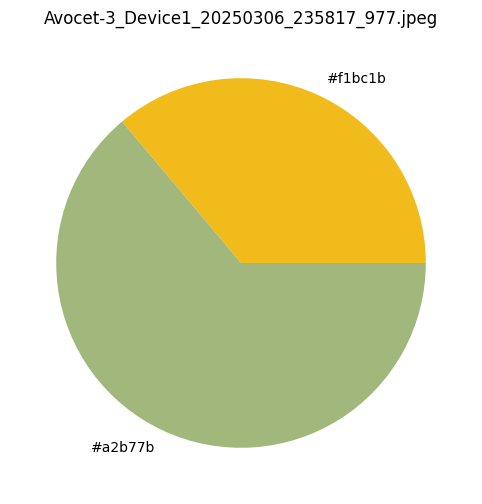

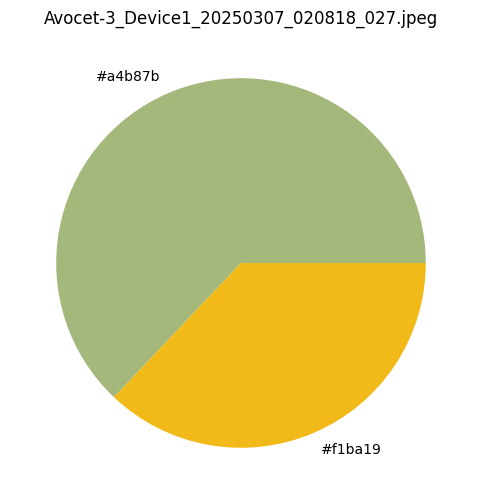

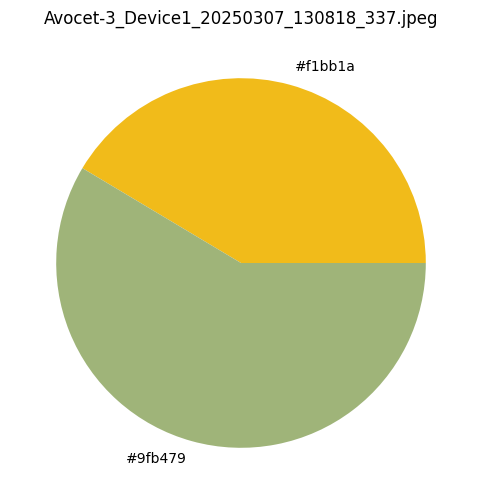

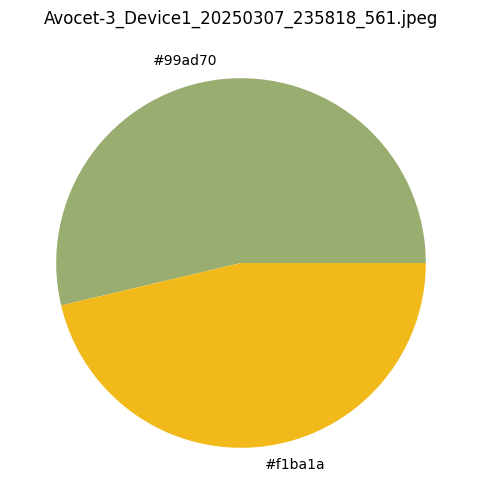

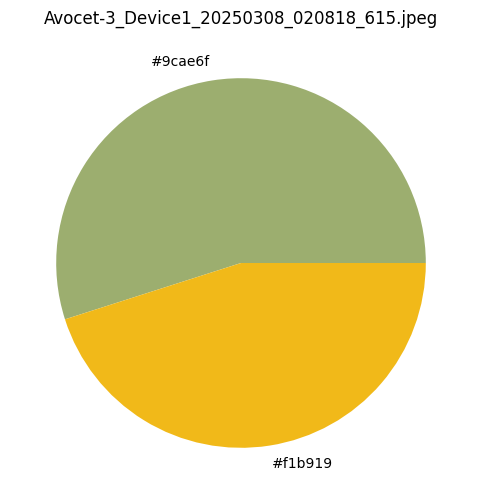

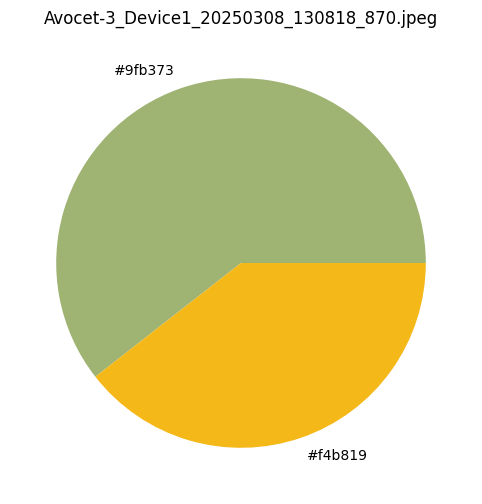

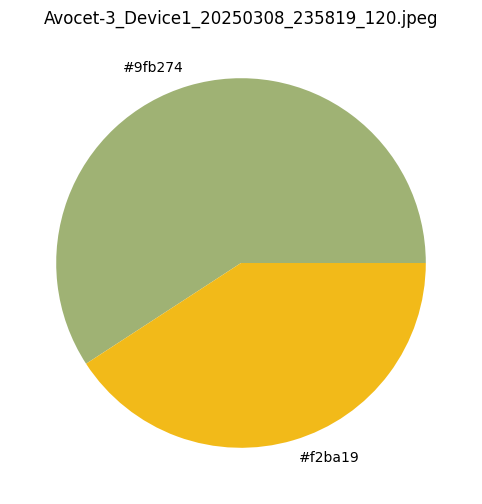

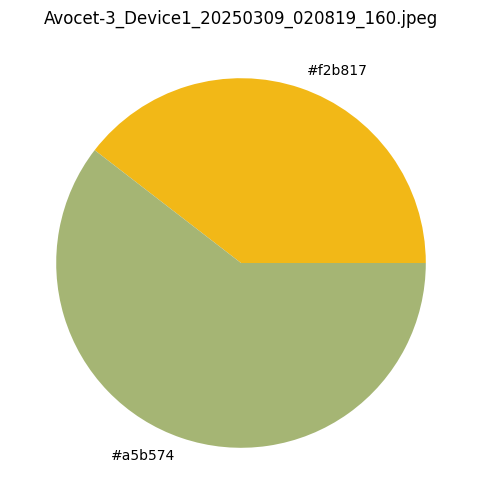

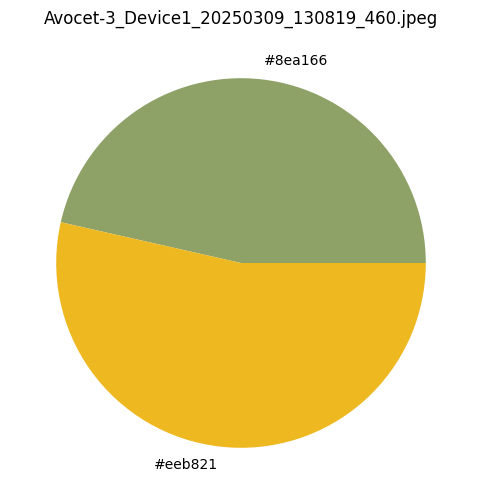

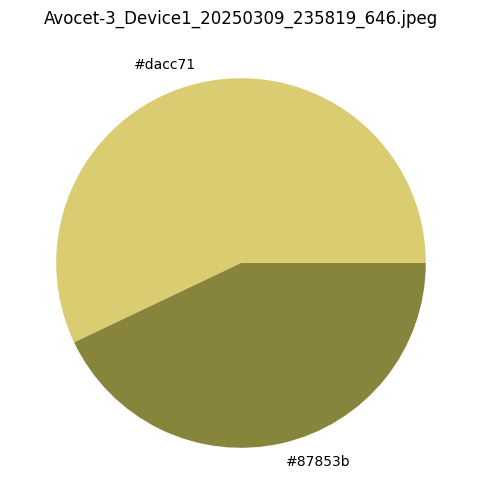

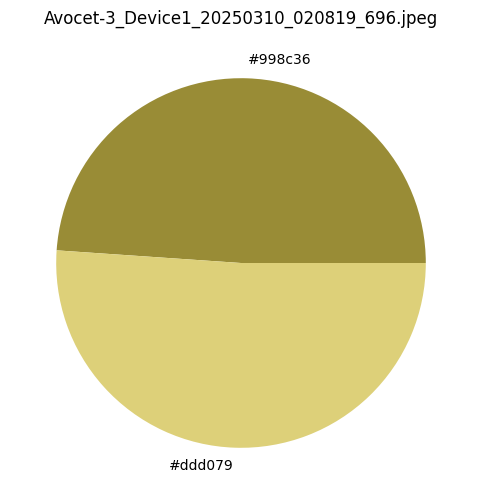

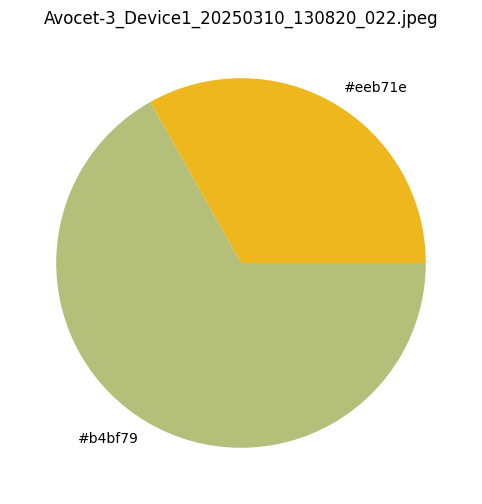

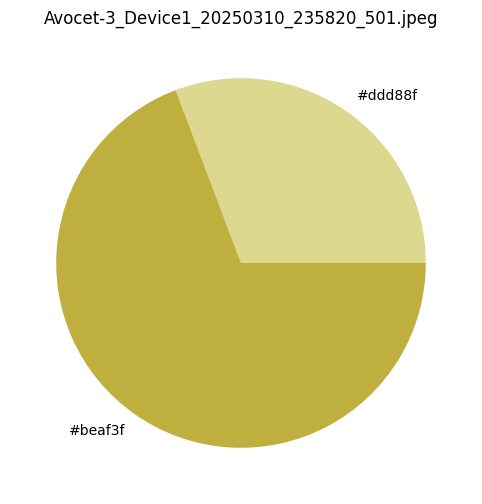

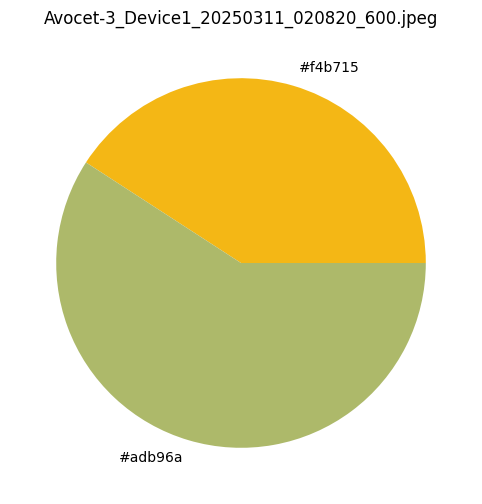

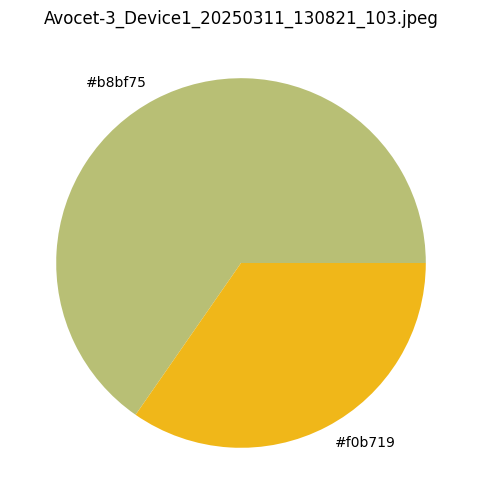

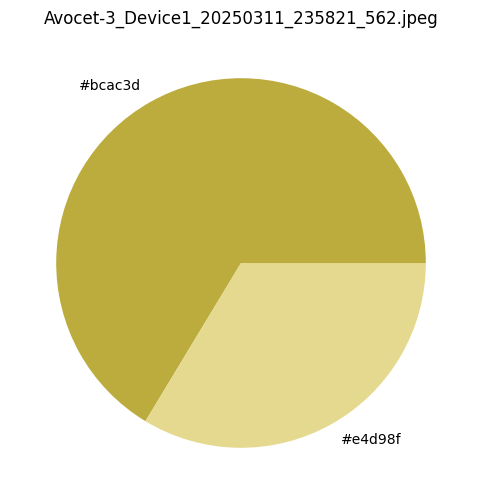

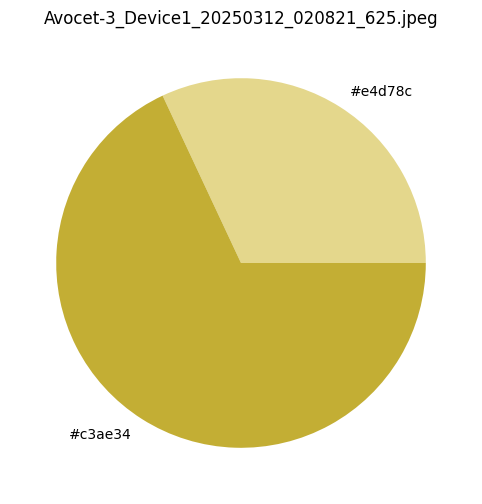

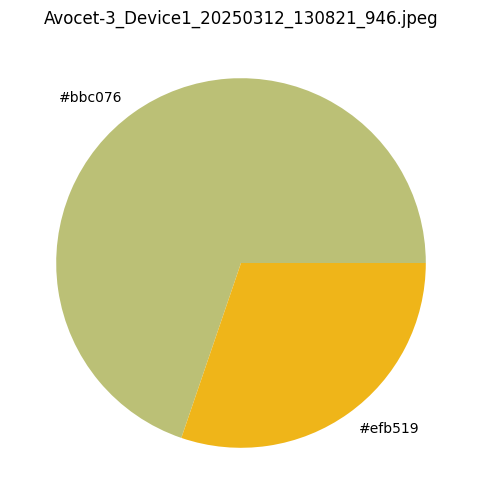

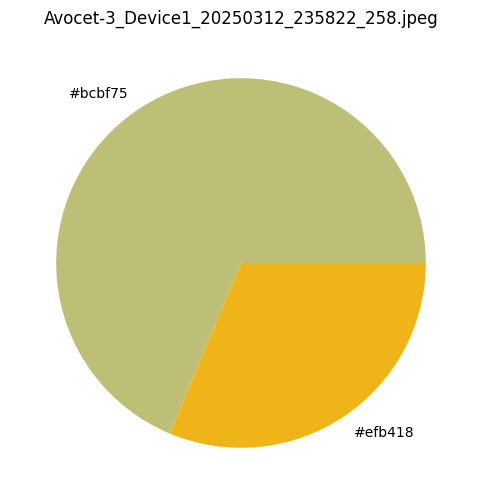

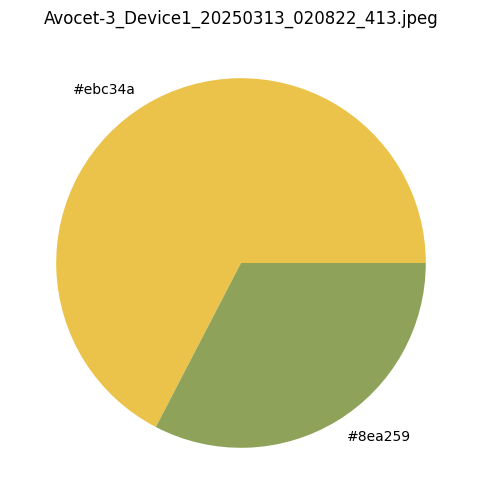

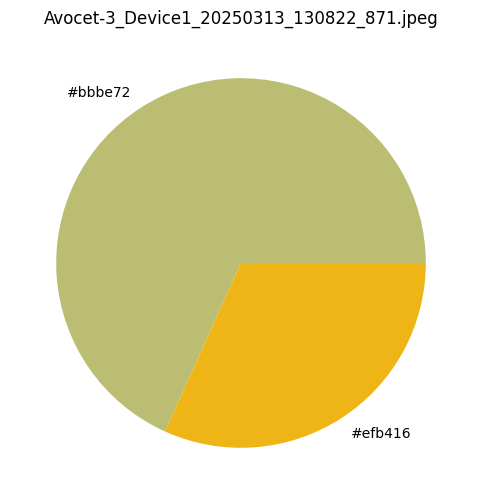

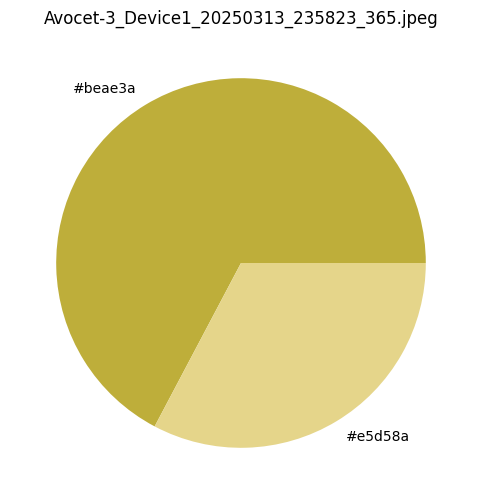

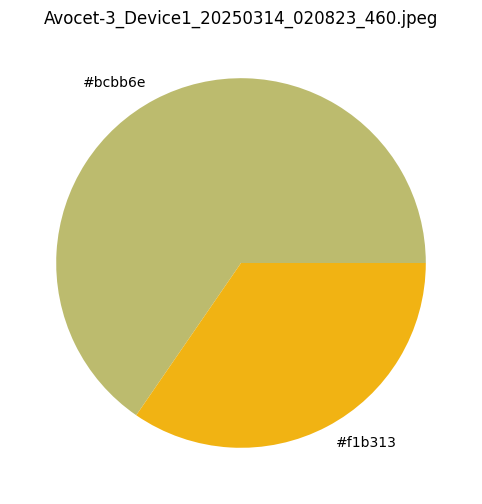

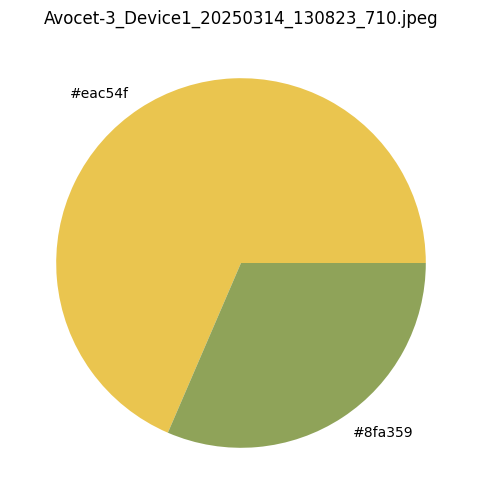

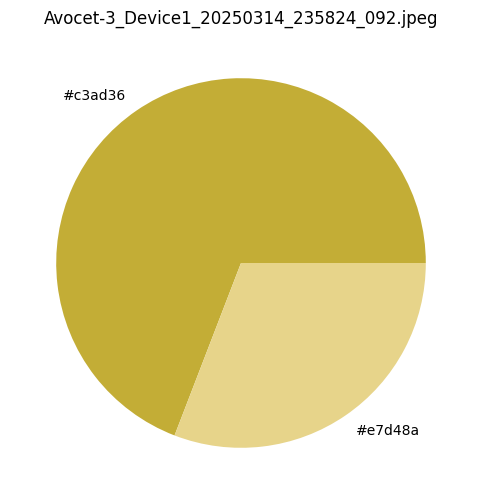

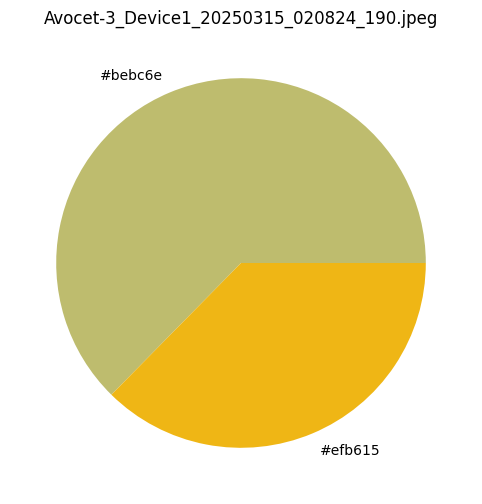

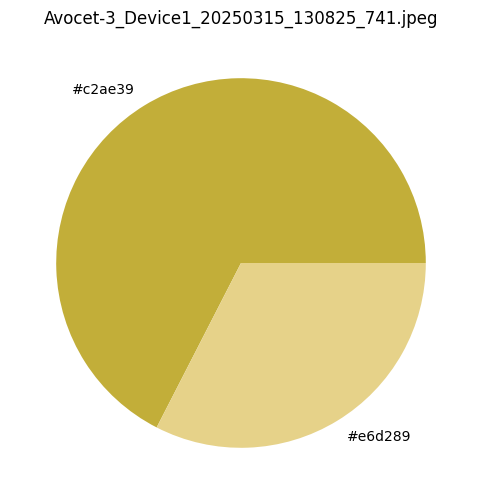

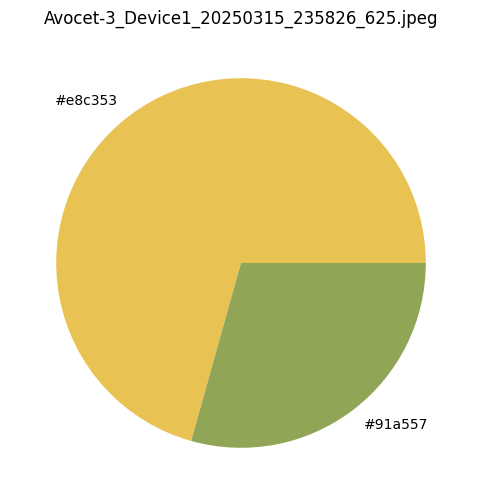

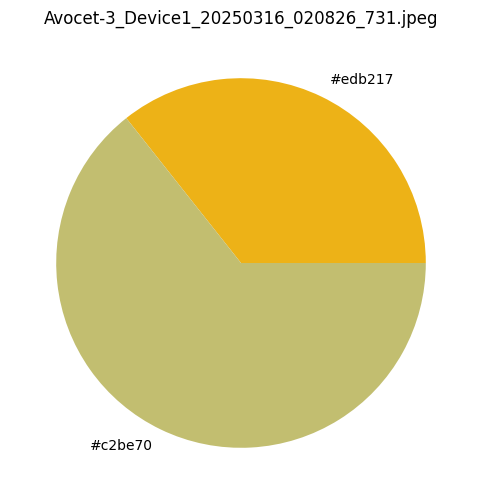

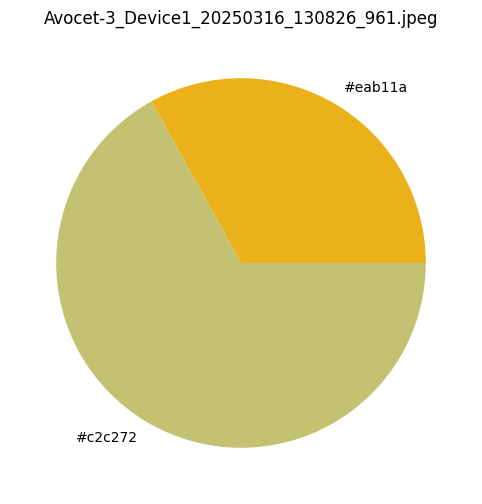

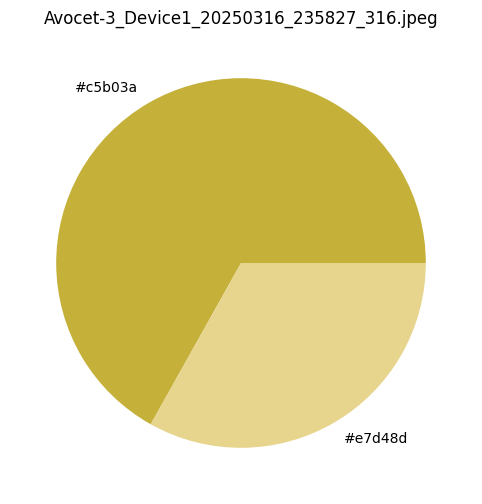

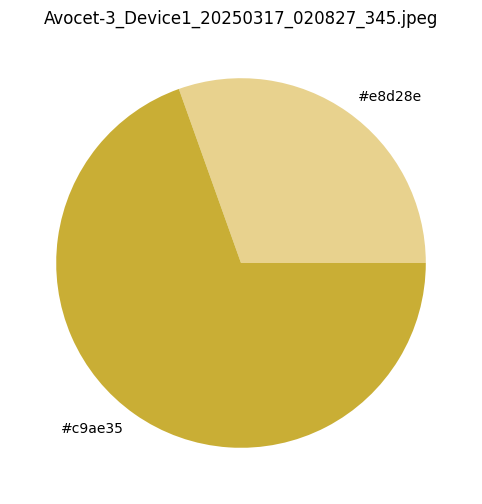

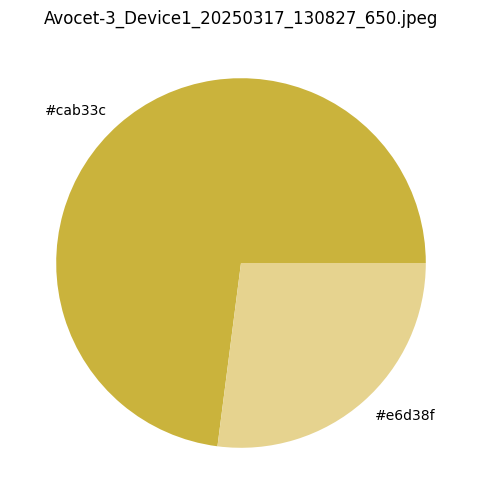

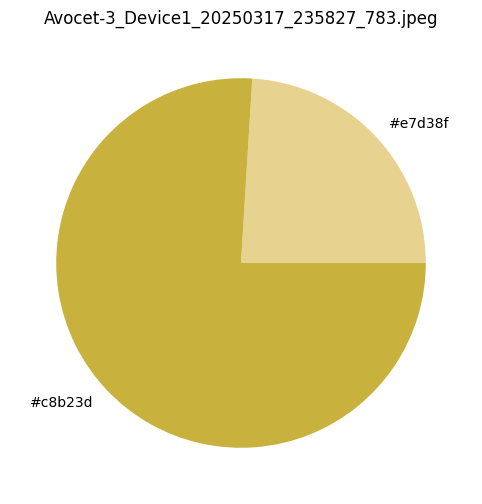

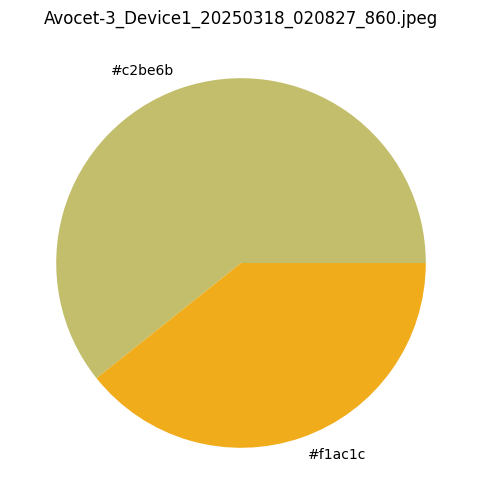

In [15]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
# calculate dominant and mean colors for the images
for i in range(len(leaves)):
    filename = leaves[i][0]
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # this cluster step is longest step
    colors = get_dominant_colors(img, 2, True, filename)
    leaves[i].append(colors)
    total_pixels = np.sum(np.all(img > 0, axis=2))
    mean_color = get_average_color(img)
    leaves[i].append(mean_color)
    leaves[i].append(total_pixels)
    area_infected = calc_pustule_percent(filename)
    leaves[i].append(area_infected)

In [16]:
df = pd.DataFrame(leaves[:][:])
df.columns = ['filename','Kmeans_results','mean_colour', 'pixels', '%_infected']
df 

,filename,Kmeans_results,mean_colour,pixels,%_infected
0,../../striperust_spring2025/auto_segment/Avoce...,"[[151.83004855755576, 185.14681519565644, 135....","[177.62323459567554, 206.90637708747946, 155.9...",416052,0.099589
1,../../striperust_spring2025/auto_segment/Avoce...,"[[203.6215571459546, 229.80763391889124, 176.7...","[178.61098397053914, 206.33562186362894, 155.5...",410307,0.169405
2,../../striperust_spring2025/auto_segment/Avoce...,"[[203.19712197350287, 231.08154408405753, 178....","[176.83698125200132, 206.65911482095865, 157.6...",415351,0.089593
3,../../striperust_spring2025/auto_segment/Avoce...,"[[202.06124379285868, 228.2534878221806, 179.2...","[170.30918807829966, 197.9330917879999, 153.19...",431113,0.071398
4,../../striperust_spring2025/auto_segment/Avoce...,"[[202.65452229299467, 226.71133757961962, 177....","[172.70526342362356, 197.60919142705677, 152.4...",396130,0.141835
...,...,...,...,...,...
75,../../striperust_spring2025/auto_segment/Avoce...,"[[197.07172765338206, 176.38139450209002, 58.5...","[203.52376117217847, 184.6147773829061, 85.424...",423485,31.052510
76,../../striperust_spring2025/auto_segment/Avoce...,"[[232.5761086695978, 210.6683979224916, 142.37...","[205.7140367947689, 181.84242549071135, 80.365...",422397,36.676607
77,../../striperust_spring2025/auto_segment/Avoce...,"[[202.0052326667898, 179.7432255653139, 60.879...","[204.54870806239646, 184.3574470438582, 82.443...",379701,35.413149
78,../../striperust_spring2025/auto_segment/Avoce...,"[[231.62513601740866, 211.52339499455988, 143....","[203.1996083031622, 182.99979224359186, 80.644...",394693,35.890454


In [17]:
df.to_csv('../../example_striperust.csv')